In [157]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import sympy as sp
from IPython.display import HTML

# **Part 1: The Wave Equation**
We solve the wave equation
$$
\partial_t^2 u - c^2 \partial_x^2 u = f(t,x), \\
u(0,x) = u^0(x), \\
\partial_t u(0,x) = v^0(x)
$$
with periodic boundary conditions
$$
u(-L) = u(L).
$$



### Question 1
Implement the finite difference scheme above for the wave equation with periodic boundary conditions.

In [167]:
def solve_wave_equation(L=1, c=1, k=12, boundary_type = "periodic", u_0 = u_0, v_0=v_0, f=f):
    a = -L
    b = L
    T = (2 * np.pi) / np.sqrt((np.pi**2) + 1)
    #f = lambda x,t: 0
    #u_0 = lambda x: 0
    #v_0 = lambda x: 0
    g = lambda u: u #fixme
    M = 2**k
    time = 0

    boundary = boundary_type

    h = (b - a) / (M)

    cfl = 0.25
    N = int(c * T / (cfl * h))
    tau = T / (N)

    xs = [a + i * h for i in range(M + 1)]
    ts = [n * tau for n in range(N + 1)]

    # U[i,n] approximates u(x_i, t_n)
    U = np.zeros((M + 1, N + 1))

    # each timestep t_{n+1}, n = 1,...,N, we explicitly update U[:,n+1]

    # initialize t_0
    for i in range(1, M):
        U[i, 0] = u_0(xs[i])

    # boundary conditions at t_0
    U[0, 0] = u_0(xs[0])
    U[M, 0] = u_0(xs[M]) #U[0, 0]

    # initialize t_1
    for i in range(1, M):
        U[i, 1] = (U[i, 0] + tau * v_0(xs[i])
                  + tau**2 * c**2 / (2 * h**2) * (U[i + 1, 0] - 2 * U[i, 0] + U[i - 1, 0])
                  + tau**2 / 2 * f(xs[i], ts[0]) - (tau**2 / 2) * g(U[i,0]) # fixme
                  )
    # absorbing boundary conditions at t_1
    if boundary == "absorbing":
        U[0, 1] = U[1,0]  #fixme
        U[M, 1] = U[M-1, 0] #fixme 

    # periodic boundary conditions at t_1
    if boundary == "periodic":
        U[0, 1] = (U[0, 0] + tau * v_0(xs[0]) 
                  + tau**2 * c**2 / (2 * h**2) * (U[1, 0] - 2 * U[0, 0] + U[M - 1, 0]) 
                  + (tau**2 / 2) * f(xs[0], ts[0]) - (tau**2 / 2) * g(U[0,0]))
        U[M, 1] = U[0, 1]
    time += tau 

    # explicit timestepping
    for n in range(1, N):
        for i in range(1, M):
            U[i, n + 1] = (
                2 * U[i, n]
                - U[i, n - 1]
                + tau**2 * c**2 / h**2 * (U[i + 1, n] - 2 * U[i, n] + U[i - 1, n]) 
                + tau**2 * f(xs[i], ts[n]) - (tau**2) * g(U[i,n]) #fixme
            )

        # absorbing boundary conditions at t_1
        if boundary == "absorbing":
              U[0, n+1] = U[1,n] #fixme 
              U[M, n+1] = U[M-1,n] #fixme 

        if boundary == "periodic": 
              U[0, n + 1] = (
                  2 * U[0, n]
                  - U[0, n - 1]
                  + tau**2 * c**2 / h**2 * (U[1, n] - 2 * U[0, n] + U[M - 1, n])
                  + tau**2 * f(xs[0], ts[n]) - (tau**2) * g(U[0,n]) #fixme
              )
              U[M, n + 1] = U[0, n + 1]
        time += tau
    print(f" Final compute time = {time - tau}")
    return U

### Question 2
Test your code with the method of manufactured solutions.

Let $L = 10$, $c = 1$, $u(t,x) = \exp(-(x-ct)^2)$.
Compute the corresponding $f$, $u^0$, and $v^0$ such that $u$ solves the PDE.
Run until final time $T := L/(2c) = N\tau$.
        
Plot $U_i^N$ versus $u(t_N,x_i)$ at the grid points $x_i$ for the highest refinement level.

In [171]:
c = 1
L = 1
T_new = (2 * np.pi) / np.sqrt(np.pi**2 + 1)

def u_exact(x, t):
    return np.cos(np.pi * x + np.sqrt((np.pi**2 + 1)) * t)

def u_0(x):
    return np.cos(np.pi * x)

def v_0(x):
    return (-np.sqrt(np.pi**2 + 1) * np.sin(np.pi * x))

def f(x, t):
    return 0.0

def mms():
    x, t= sp.symbols('x, t')
    c = sp.Integer(1)
    
    #omega = sp.Rational(1, 2)

    #HINT: use sp for the functions, for example, for sin, use sp.sin
    u_exact = sp.cos(sp.pi * x + sp.sqrt(sp.pi**2 + 1) * t) #fixme 
    dtt_u_exact = sp.diff(u_exact, t, 2)
    d_xx_u_exact = sp.diff(u_exact, x, 2)
    f = dtt_u_exact - (c**2 * d_xx_u_exact) + (u_exact) #fixme 
    return(sp.trigsimp(sp.simplify(f)))


def test_wave_equation():
    K = 12
    a = -L
    b = L
    h_list = []
    e_list = []

    k_vals = [10,11,12]
    for K in k_vals:
        M = 2**K
        h = (b - a) / (M)
        h_list.append(h)

        xs = [a + i * h for i in range(M + 1)]
        U_exact = [u_exact(x, T_new) for x in xs]

        U = solve_wave_equation(L = L, c = c, k = K, boundary_type = "periodic", u_0 = u_0, v_0 = v_0, f = f)

        E_M = max([abs(U_exact[i] - U[i, -1]) for i in range (M + 1)])
        e_list.append(E_M)
        print("{:e}\t{:e}".format(h, E_M))
    


    
    plt.loglog(h_list, e_list, linestyle='-', marker='o', linewidth=2, label="Numerical Error")    
    plt.xlabel("Mesh Size")
    plt.ylabel("Errors")
    plt.legend()    
    plt.show()

print(mms())
test_wave_equation()

0
 Final compute time = 1.905292741780166
1.953125e-03	8.271365e-06


KeyboardInterrupt: 

### Question 3
Let
	      \begin{equation}
		      e_k := \max_{0\leq i \leq M} |U_i^N - u(t_N,x_i)|
	      \end{equation}
	      denote the discrete error at the final time for mesh refinement level $k$, where we recall that $M = 2^k$.
	      Create a log--log plot of $e_k$ versus the mesh size $h_k := 2L/M = L / 2^{k-1}$ for $k = 10,11,12$.

True final time = 1.9057810279773746
 Final compute time = 1.9048042053079657


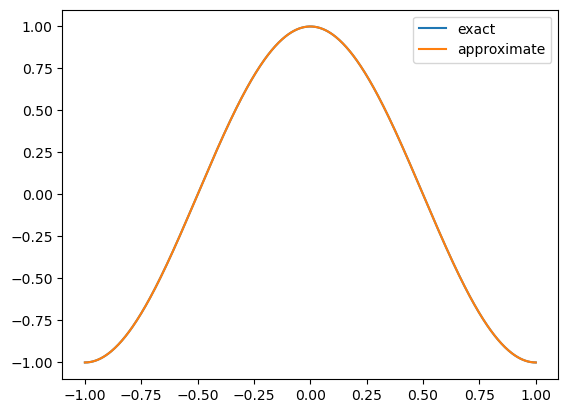

In [170]:
#def compute_errors():

def u_exact(x, t):
    return np.cos(np.pi * x + np.sqrt((np.pi**2 + 1)) * t)

def test_wave_eq():
    L = 1
    c = 1
    K = 9
    M = 2**K
    cfl = 0.25
    a = -L
    b = L
    t = 5

    # exact solution at the discrete grid points
    h = (b - a) / (M)
    T = (2 * np.pi) / np.sqrt(np.pi**2 + 1)
    print(f"True final time = {T}")

    N = int(c * T / (cfl * h))
    tau = T / N

    xs = [a + i * h for i in range(M + 1)]
    U_exact = [u_exact(x, T) for x in xs]


    # approximate solution
    U_approx = solve_wave_equation(L = L, c = c, k = K, boundary_type = "periodic", u_0 = u_0, v_0 = v_0, f = f)


    # plot solutions
    plt.plot(xs, U_exact, label="exact")
    plt.plot(xs, U_approx[:,-1], label="approximate")
    plt.legend()
    plt.show()


test_wave_eq() 

### Question 4
Make an animation of your approximate solution $U_i^n$.

In [ ]:
def make_animation():

### Question 5
Now set $f(t,x) = 0$ and $v^0 = 0$.
	      Experiment with different periodic initial conditions $u^0$.
	      Take snapshots of your simulations and create animations over the circle in 3d.

In [ ]:
def animate_over_circle(t_values,s_values,u_values):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.set_title('t = {:.2f}'.format(t_values[0]))
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('u')
    z_min = min(min(u_value) for u_value in u_values)
    z_min -= 0.1 if abs(z_min) < 0.1 else 0.1 * abs(z_min)
    z_max = max(max(u_value) for u_value in u_values)
    z_max += 0.1 if abs(z_max) < 0.1 else 0.1 * abs(z_max)
    ax.set_zlim(z_min,z_max)
    L = -s_values[0]
    r = #fixme
    xs = #fixme
    ys = #fixme
    line = ax.plot(xs, ys, u_values[0])[0]
    def animate(frame):
        ax.set_title('t = {:.2f}'.format(t_values[frame]))
        line.set_data_3d(xs, ys, u_values[frame])
        return line
    anim = animation.FuncAnimation(fig,animate,frames=len(u_values),interval=30)
    plt.close()
    video = HTML(anim.to_html5_video())
    # If you're getting an "ffmpeg0" error, try using the following command instead: 
    # video = HTML(anim.to_jshtml())
    return video

L=10
a = -L
b = L
c = 1
T = L / (2*c)
k=12
M = 2**k
h = (b - a) / (M)
N = int(c * T / h)
tau = T / (N)

xs = [a + i * h for i in range(M + 1)]
ts = [n * tau for n in range(N + 1)]

U = #fixme
animate_over_circle() #fixme
    

In [ ]:
### Dispersive PDE Solver ###


def solve_dispersive_pde_equation(L=10, c=1, k=12, boundary_type="periodic"):
    a = -L
    b = L
    T = L / (2*c)
    f = lambda x,t: 0
    u_0 = lambda x: np.exp(-(x**2))
    v_0 = lambda x: 2*c*x*np.exp(-(x**2))
    g = lambda u: #fixme
    M = 2**k

    boundary = boundary_type

    h = (b - a) / (M)

    N = int(c * T / h)
    tau = T / (N)

    xs = [a + i * h for i in range(M + 1)]
    ts = [n * tau for n in range(N + 1)]

    # U[i,n] approximates u(x_i, t_n)
    U = np.zeros((M + 1, N + 1))

    # each timestep t_{n+1}, n = 1,...,N, we explicitly update U[:,n+1]

    # initialize t_0
    for i in range(1, M):
        U[i, 0] = u_0(xs[i])

    # boundary conditions at t_0
    U[0, 0] = u_0(xs[0])
    U[M, 0] = u_0(xs[M]) #U[0, 0]

    # initialize t_1
    for i in range(1, M):
        U[i, 1] = (U[i, 0] + tau * v_0(xs[i])
                  + tau**2 * c**2 / (2 * h**2) * (U[i + 1, 0] - 2 * U[i, 0] + U[i - 1, 0])
                  + tau**2 / 2 * f(xs[i], ts[0]) # fixme
                  )
    # absorbing boundary conditions at t_1
    if boundary == "absorbing":
      U[0, 1] = #fixme
      U[M, 1] = #fixme 

    # periodic boundary conditions at t_1
    if boundary == "periodic":
      U[0, 1] = (U[0, 0] + tau * v_0(xs[0])
                  + tau**2 * c**2 / (2 * h**2) * (U[1, 0] - 2 * U[0, 0] + U[M - 1, 0]) 
                  + tau**2 / 2 * f(xs[0], ts[0]) # fixme
              )
      U[M, 1] = U[0, 1]


    # explicit timestepping
    for n in range(1, N):
        for i in range(1, M):
            U[i, n + 1] = (
                2 * U[i, n]
                - U[i, n - 1]
                + tau**2 * c**2 / h**2 * (U[i + 1, n] - 2 * U[i, n] + U[i - 1, n]) 
                + tau**2 * f(xs[i], ts[n]) #fixme
            )

        # absorbing boundary conditions at t_1
        if boundary == "absorbing":
              U[0, n+1] = #fixme 
              U[M, n+1] = #fixme 

        if boundary == "periodic": 
              U[0, n + 1] = (
                  2 * U[0, n]
                  - U[0, n - 1]
                  + tau**2 * c**2 / h**2 * (U[1, n] - 2 * U[0, n] + U[M - 1, n])
                  + tau**2 * f(xs[0], ts[n]) #fixme
              )
              U[M, n + 1] = U[0, n + 1]

    return U